In [34]:
import sys
!{sys.executable} -m pip install lifelines

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [35]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 1: DATA LOADING AND PREPARATION
# TEDS-D 2023 Survival Analysis
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

# ── LOADING DATA ────────────────────────────────────────────────────
df = pd.read_csv('tedsd_puf_2023 2.csv')
print(f"Starting rows: {df.shape[0]:,}")
print(f"Starting columns: {df.shape[1]:,}")

# ── SELECTING COLUMNS ────────────────────────────────────────────────
# EDUC (47.2%), LIVARAG (45.7%), NOPRIOR (40.4%), MARSTAT (32.1%)
# excluded due to missing data rates exceeding 30%
cols = ['LOS', 'REASON',
        'AGE', 'SEX', 'RACE',
        'EMPLOY', 'SUB1', 'FREQ1',
        'PSYPROB', 'PSOURCE',
        'SERVICES', 'HLTHINS']
df = df[cols].copy()

# ── RECODING LOS ────────────────────────────────────────────────────
# values 1-30 are exact days
# values 31-37 are interval category codes, recoded to midpoints
# must happen before missing value cleaning
los_recode = {
    31: 38,    # 31-45 days → midpoint 38
    32: 53,    # 46-60 days → midpoint 53
    33: 75,    # 61-90 days → midpoint 75
    34: 105,   # 91-120 days → midpoint 105
    35: 150,   # 121-180 days → midpoint 150
    36: 270,   # 181-365 days → midpoint 270
    37: 548    # 365+ days → approximate midpoint ~1.5 years
}
df['LOS_days'] = df['LOS'].replace(los_recode)

# ── RECODING AGE ────────────────────────────────────────────────────
# values 1-12 are interval category codes, recoded to midpoints
# same approach as LOS
age_recode = {
    1:  13,    # 12-14 years → midpoint 13
    2:  16,    # 15-17 years → midpoint 16
    3:  19,    # 18-20 years → midpoint 19
    4:  22,    # 21-24 years → midpoint 22
    5:  27,    # 25-29 years → midpoint 27
    6:  32,    # 30-34 years → midpoint 32
    7:  37,    # 35-39 years → midpoint 37
    8:  42,    # 40-44 years → midpoint 42
    9:  47,    # 45-49 years → midpoint 47
    10: 52,    # 50-54 years → midpoint 52
    11: 59,    # 55-64 years → midpoint 59
    12: 70     # 65+ years → approximate midpoint 70
}
df['AGE_years'] = df['AGE'].replace(age_recode)
print(f"\nAGE_years range: {df['AGE_years'].min()} to {df['AGE_years'].max()} years")

# ── CLEANING MISSING VALUES ──────────────────────────────────────────
# removing records with missing values for variables under 30% missing
# HLTHINS handled separately below bc of 42% missing rate
vars_to_clean = ['LOS', 'REASON', 'AGE', 'SEX', 'RACE',
                 'EMPLOY', 'SUB1', 'FREQ1',
                 'PSYPROB', 'PSOURCE', 'SERVICES']
df = df[(df[vars_to_clean] > 0).all(axis=1)]

# HLTHINS: recode -9 (missing) as 5 (unknown/not reported)
# preserves rows rather than dropping 42% of sample
df['HLTHINS'] = df['HLTHINS'].replace(-9, 5)

# verifing cleaning results
print(f"After cleaning: {df.shape[0]:,} rows")
print(f"Rows retained: {df.shape[0]/51971*100:.1f}% of original sample")

# ── CREATING EVENT TYPE COLUMN (COMPETING RISKS) ───────────────────
# categorizes all discharge outcomes
# dropout (REASON=2) is the primary event of interest
# death, incarceration, facility termination are competing events
# completed treatment and transfers are censored
def categorize_reason(reason):
    if reason == 2:
        return 1    # dropout — primary event of interest
    elif reason == 6:
        return 2    # death — competing event
    elif reason == 5:
        return 3    # incarcerated — competing event
    elif reason == 3:
        return 4    # terminated by facility — competing event
    else:
        return 0    # censored (completed=1, transferred=4, other=7)

df['event_type'] = df['REASON'].apply(categorize_reason)

# binary dropout column retained for log-rank tests
# log-rank tests require binary event indicator
df['dropped_out'] = (df['REASON'] == 2).astype(int)

# verifing event distribution
print(f"\nDropout rate: {df['dropped_out'].mean():.1%}")
print("\nEvent type distribution:")
event_labels = {0: 'Censored', 1: 'Dropout', 2: 'Death',
                3: 'Incarcerated', 4: 'Terminated by facility'}
for code, label in event_labels.items():
    count = (df['event_type'] == code).sum()
    pct = count / len(df) * 100
    print(f"  {label:<30} n={count:>6,} ({pct:.1f}%)")

# ── APPLYING JITTER ──────────────────────────────────────────────────
# small random jitter (0-0.5 days) applied to LOS_days
# resolves tied event times required by Aalen-Johansen estimator
# jitter is too small to meaningfully affect results
np.random.seed(42)
df['LOS_days'] = df['LOS_days'] + np.random.uniform(0, 0.5, size=len(df))
print(f"\nJitter applied: LOS_days range = "
      f"{df['LOS_days'].min():.2f} to {df['LOS_days'].max():.2f} days")

Starting rows: 51,971
Starting columns: 76

AGE_years range: 13 to 70 years
After cleaning: 22,028 rows
Rows retained: 42.4% of original sample

Dropout rate: 20.6%

Event type distribution:
  Censored                       n=14,955 (67.9%)
  Dropout                        n= 4,546 (20.6%)
  Death                          n=    50 (0.2%)
  Incarcerated                   n=   376 (1.7%)
  Terminated by facility         n= 2,101 (9.5%)

Jitter applied: LOS_days range = 1.00 to 548.50 days


In [36]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 2: DESCRIPTIVE STATISTICS
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print(f"Total analytic sample: {len(df):,} participants")
print(f"Total dropout events: {df['dropped_out'].sum():,} "
      f"({df['dropped_out'].mean():.1%})")
print("=" * 60)

# NOTE: Mean and median LOS are descriptive statistics for the
# full analytic sample including both dropout and non-dropout
# participants. These are NOT estimated mean survival times.
# Mean survival time cannot be calculated because not all
# participants experienced the event (Park et al., 2021).
print("\nLENGTH OF STAY — DESCRIPTIVE STATISTICS")
print("(observed stay durations, not estimated survival times)")
print(f"  Mean LOS:   {df['LOS_days'].mean():.1f} days")
print(f"  Median LOS: {df['LOS_days'].median():.1f} days")
print(f"  Min:        {df['LOS_days'].min():.1f} days")
print(f"  Max:        {df['LOS_days'].max():.1f} days")

# helper function: calculates n, % of sample, dropout n, dropout rate
def desc_table(var, labels, df):
    rows = []
    for code, label in labels.items():
        mask = df[var] == code
        n = mask.sum()
        pct = n / len(df) * 100
        dropout_n = df.loc[mask, 'dropped_out'].sum()
        dropout_rate = df.loc[mask, 'dropped_out'].mean() * 100
        rows.append({
            'Group': label,
            'n': f"{n:,}",
            '% of Sample': f"{pct:.1f}%",
            'Dropout n': f"{dropout_n:,}",
            'Dropout Rate': f"{dropout_rate:.1f}%"
        })
    return pd.DataFrame(rows).set_index('Group')

print("\nSEX")
print(desc_table('SEX', {1: 'Male', 2: 'Female'}, df).to_string())

print("\nRACE/ETHNICITY")
print(desc_table('RACE', {
    1: 'Alaska Native', 2: 'American Indian',
    4: 'Black or African American', 5: 'White',
    6: 'Asian', 7: 'Other single race',
    8: 'Two or more races', 9: 'Native Hawaiian/Pacific Islander'
}, df).to_string())

print("\nAGE GROUP")
age_labels_desc = {
    13: '12-14', 16: '15-17', 19: '18-20', 22: '21-24',
    27: '25-29', 32: '30-34', 37: '35-39', 42: '40-44',
    47: '45-49', 52: '50-54', 59: '55-64', 70: '65+'
}
rows = []
for midpoint, label in age_labels_desc.items():
    mask = df['AGE_years'] == midpoint
    n = mask.sum()
    pct = n / len(df) * 100
    dropout_n = df.loc[mask, 'dropped_out'].sum()
    dropout_rate = df.loc[mask, 'dropped_out'].mean() * 100 if n > 0 else 0
    rows.append({'Group': label, 'n': f"{n:,}",
                 '% of Sample': f"{pct:.1f}%",
                 'Dropout n': f"{dropout_n:,}",
                 'Dropout Rate': f"{dropout_rate:.1f}%"})
print(pd.DataFrame(rows).set_index('Group').to_string())

print("\nEMPLOYMENT STATUS")
print(desc_table('EMPLOY', {
    1: 'Full-time', 2: 'Part-time',
    3: 'Unemployed', 4: 'Not in labor force'
}, df).to_string())

print("\nHEALTH INSURANCE")
print(desc_table('HLTHINS', {
    1: 'Private', 2: 'Medicaid',
    3: 'Medicare/Other', 4: 'None', 5: 'Unknown†'
}, df).to_string())
print("† Unknown reflects -9 (missing/not collected) recoded to preserve sample size")

print("\nPRIMARY SUBSTANCE")
print(desc_table('SUB1', {
    2: 'Alcohol', 3: 'Cocaine/crack', 4: 'Marijuana/hashish',
    5: 'Heroin', 6: 'Non-prescription methadone', 7: 'Other opiates/synthetics',
    8: 'PCP', 9: 'Hallucinogens', 10: 'Methamphetamine/speed',
    11: 'Other amphetamines', 12: 'Other stimulants', 13: 'Benzodiazepines',
    14: 'Other tranquilizers', 15: 'Barbiturates', 16: 'Other sedatives/hypnotics',
    17: 'Inhalants', 18: 'Over-the-counter medications', 19: 'Other drugs'
}, df).to_string())
print("† Groups with n<100 excluded from survival analyses, log-rank tests, and Cox model")

print("\nCO-OCCURRING MENTAL HEALTH DISORDER")
print(desc_table('PSYPROB', {
    1: 'Yes — co-occurring disorder', 2: 'No co-occurring disorder'
}, df).to_string())

print("\nREFERRAL SOURCE")
print(desc_table('PSOURCE', {
    1: 'Individual/self', 2: 'Alcohol/drug provider',
    3: 'Other health provider', 4: 'School',
    5: 'Employer', 6: 'Other community',
    7: 'Court/criminal justice'
}, df).to_string())

print("\nTREATMENT SETTING")
print(desc_table('SERVICES', {
    1: 'Detox - hospital inpatient', 2: 'Detox - free-standing residential',
    3: 'Rehab/residential - hospital', 4: 'Rehab/residential - short term',
    5: 'Rehab/residential - long term', 6: 'Ambulatory - intensive outpatient',
    7: 'Ambulatory - non-intensive outpatient', 8: 'Ambulatory - detoxification'
}, df).to_string())

print("\nFREQUENCY OF USE AT INTAKE")
print(desc_table('FREQ1', {
    1: 'No use past month', 2: 'Some use', 3: 'Daily use'
}, df).to_string())

print("\nEVENT TYPE DISTRIBUTION")
rows = []
for code, label in {
    0: 'Censored (completed/transferred/other)',
    1: 'Dropout', 2: 'Death',
    3: 'Incarcerated', 4: 'Terminated by facility'
}.items():
    n = (df['event_type'] == code).sum()
    pct = n / len(df) * 100
    rows.append({'Event': label, 'n': f"{n:,}", '% of Sample': f"{pct:.1f}%"})
print(pd.DataFrame(rows).set_index('Event').to_string())

DESCRIPTIVE STATISTICS
Total analytic sample: 22,028 participants
Total dropout events: 4,546 (20.6%)

LENGTH OF STAY — DESCRIPTIVE STATISTICS
(observed stay durations, not estimated survival times)
  Mean LOS:   97.6 days
  Median LOS: 53.0 days
  Min:        1.0 days
  Max:        548.5 days

SEX
             n % of Sample Dropout n Dropout Rate
Group                                            
Male    13,340       60.6%     2,472        18.5%
Female   8,688       39.4%     2,074        23.9%

RACE/ETHNICITY
                                       n % of Sample Dropout n Dropout Rate
Group                                                                      
Alaska Native                        621        2.8%       102        16.4%
American Indian                      464        2.1%        47        10.1%
Black or African American          3,918       17.8%       919        23.5%
White                             16,111       73.1%     3,324        20.6%
Asian                       

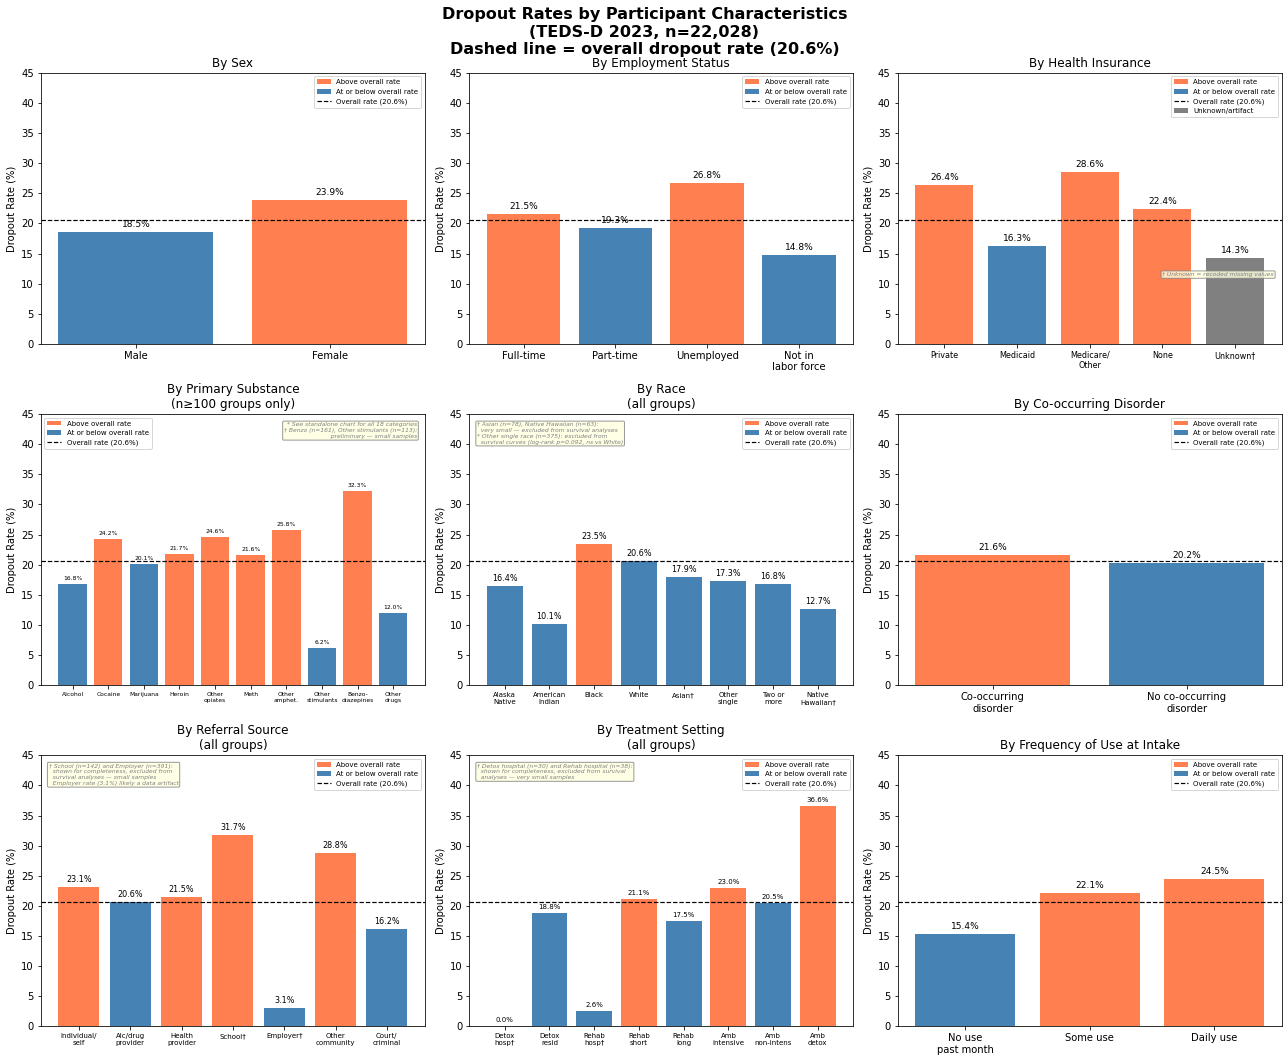

Saved: descriptive_dropout_rates.png


In [44]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 3: DESCRIPTIVE BAR CHARTS — 3x3 GRID
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.lines as mlines

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Dropout Rates by Participant Characteristics\n'
             '(TEDS-D 2023, n=22,028)\n'
             'Dashed line = overall dropout rate (20.6%)',
             fontsize=16, fontweight='bold')

overall_rate = 20.6

def get_legend_elements():
    return [
        Patch(facecolor='coral', label='Above overall rate'),
        Patch(facecolor='steelblue', label='At or below overall rate'),
        mlines.Line2D([0], [0], color='black', linestyle='--',
                      linewidth=1.2, label=f'Overall rate ({overall_rate}%)')
    ]

# ── Graph 1: By Sex ───────────────────────────────────────────────
ax = axes[0, 0]
sex_data = {'Male': 18.5, 'Female': 23.9}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in sex_data.values()]
bars = ax.bar(sex_data.keys(), sex_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Sex')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
for bar, val in zip(bars, sex_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')

# ── Graph 2: By Employment Status ────────────────────────────────
ax = axes[0, 1]
employ_data = {'Full-time': 21.5, 'Part-time': 19.3,
               'Unemployed': 26.8, 'Not in\nlabor force': 14.8}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in employ_data.values()]
bars = ax.bar(employ_data.keys(), employ_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Employment Status')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
for bar, val in zip(bars, employ_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')

# ── Graph 3: By Health Insurance ─────────────────────────────────
ax = axes[0, 2]
hlthins_data = {'Private': 26.4, 'Medicaid': 16.3,
                'Medicare/\nOther': 28.6, 'None': 22.4, 'Unknown†': 14.3}
colors = ['gray' if k == 'Unknown†'
          else 'coral' if v > overall_rate
          else 'steelblue'
          for k, v in hlthins_data.items()]
bars = ax.bar(hlthins_data.keys(), hlthins_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Health Insurance')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, hlthins_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)
hlthins_legend = get_legend_elements() + [
    Patch(facecolor='gray', label='Unknown/artifact')]
ax.legend(handles=hlthins_legend, fontsize=7, loc='upper right')
ax.annotate('† Unknown = recoded missing values',
            xy=(0.98, 0.25), xycoords='axes fraction',
            fontsize=6, color='gray', style='italic', ha='right',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

# ── Graph 4: By Primary Substance (n≥100 only) ───────────────────
ax = axes[1, 0]
sub_data = {'Alcohol': 16.8, 'Cocaine': 24.2, 'Marijuana': 20.1,
            'Heroin': 21.7, 'Other\nopiates': 24.6, 'Meth': 21.6,
            'Other\namphet.': 25.8, 'Other\nstimulants': 6.2,
            'Benzo-\ndiazepines': 32.3, 'Other\ndrugs': 12.0}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in sub_data.values()]
bars = ax.bar(sub_data.keys(), sub_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Primary Substance\n(n≥100 groups only)')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=6)
for bar, val in zip(bars, sub_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=6)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper left')
ax.annotate('* See standalone chart for all 18 categories\n'
            '† Benzo (n=161), Other stimulants (n=113):\n'
            '  preliminary — small samples',
            xy=(0.98, 0.97), xycoords='axes fraction',
            fontsize=6, color='gray', style='italic',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

# ── Graph 5: By Race (all groups) ───────────────────────
ax = axes[1, 1]
race_data = {'Alaska\nNative': 16.4, 'American\nIndian': 10.1,
             'Black': 23.5, 'White': 20.6,
             'Asian†': 17.9, 'Other\nsingle': 17.3,
             'Two or\nmore': 16.8, 'Native\nHawaiian†': 12.7}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in race_data.values()]
bars = ax.bar(race_data.keys(), race_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Race\n(all groups)')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, race_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=8)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')
ax.annotate('† Asian (n=78), Native Hawaiian (n=63):\n'
            '  very small — excluded from survival analyses\n'
            '* Other single race (n=375): excluded from\n'
            '  survival curves (log-rank p=0.092, ns vs White)',
            xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=6, color='gray', style='italic', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

# ── Graph 6: By Co-occurring Disorder ────────────────────────────
ax = axes[1, 2]
psyprob_data = {'Co-occurring\ndisorder': 21.6,
                'No co-occurring\ndisorder': 20.2}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in psyprob_data.values()]
bars = ax.bar(psyprob_data.keys(), psyprob_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Co-occurring Disorder')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
for bar, val in zip(bars, psyprob_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')

# ── Graph 7: By Referral Source (all groups) ─────────────────────
ax = axes[2, 0]
psource_data = {'Individual/\nself': 23.1, 'Alc/drug\nprovider': 20.6,
                'Health\nprovider': 21.5, 'School†': 31.7,
                'Employer†': 3.1, 'Other\ncommunity': 28.8,
                'Court/\ncriminal': 16.2}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in psource_data.values()]
bars = ax.bar(psource_data.keys(), psource_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Referral Source\n(all groups)')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, psource_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=8)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')
ax.annotate('† School (n=142) and Employer (n=391):\n'
            '  shown for completeness, excluded from\n'
            '  survival analyses — small samples\n'
            '  Employer rate (3.1%) likely a data artifact',
            xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=6, color='gray', style='italic', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

# ── Graph 8: By Treatment Setting (all groups) ───────────────────
ax = axes[2, 1]
services_data = {'Detox\nhosp†': 0.0, 'Detox\nresid': 18.8,
                 'Rehab\nhosp†': 2.6, 'Rehab\nshort': 21.1,
                 'Rehab\nlong': 17.5, 'Amb\nintensive': 23.0,
                 'Amb\nnon-intens': 20.5, 'Amb\ndetox': 36.6}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in services_data.values()]
bars = ax.bar(services_data.keys(), services_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Treatment Setting\n(all groups)')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, services_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=7)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')
ax.annotate('† Detox hospital (n=30) and Rehab hospital (n=38):\n'
            '  shown for completeness, excluded from survival\n'
            '  analyses — very small samples',
            xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=6, color='gray', style='italic', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

# ── Graph 9: By Frequency of Use ─────────────────────────────────
ax = axes[2, 2]
freq_data = {'No use\npast month': 15.4, 'Some use': 22.1,
             'Daily use': 24.5}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in freq_data.values()]
bars = ax.bar(freq_data.keys(), freq_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('By Frequency of Use at Intake')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
for bar, val in zip(bars, freq_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)
ax.legend(handles=get_legend_elements(), fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('descriptive_dropout_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: descriptive_dropout_rates.png")

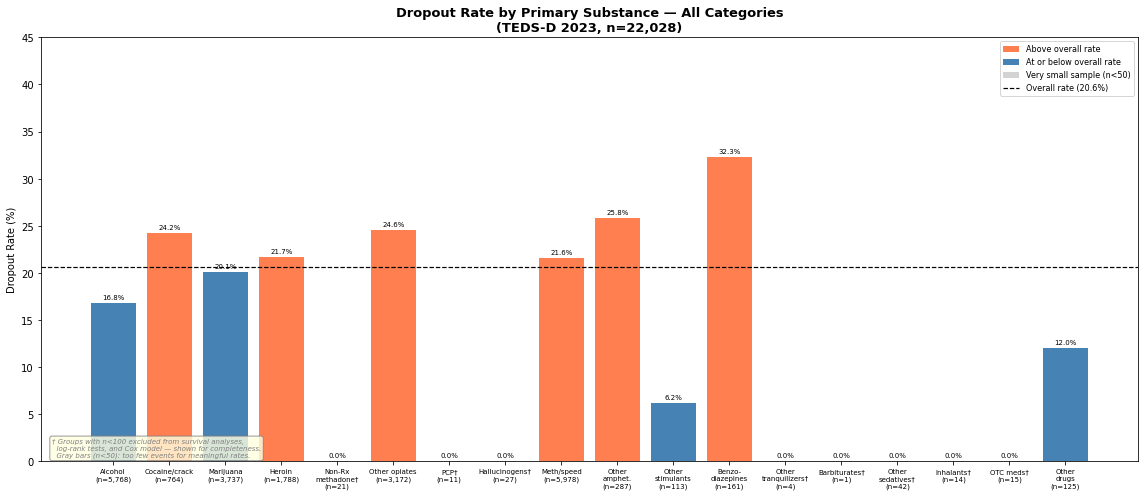

Saved: descriptive_dropout_substance_all.png


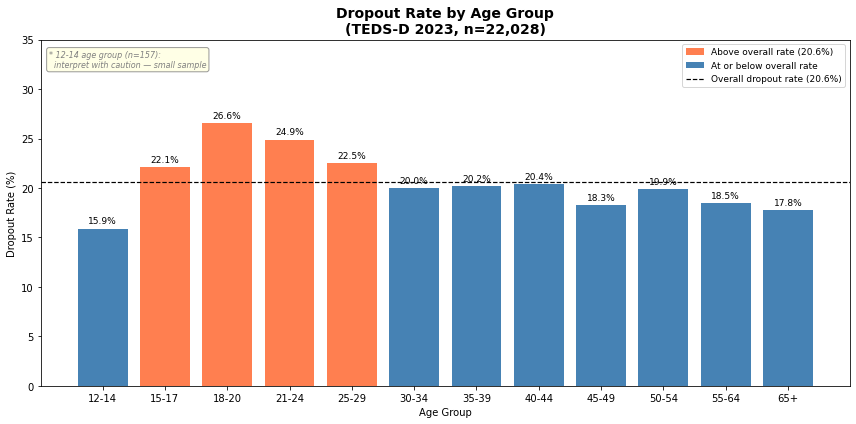

Saved: descriptive_dropout_age.png


In [38]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 4: STANDALONE CHARTS — SUBSTANCE (ALL 18) AND AGE
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

overall_rate = 20.6

# ── Substance Graph — All 18 Categories ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

sub_all_data = {
    'Alcohol\n(n=5,768)': 16.8,
    'Cocaine/crack\n(n=764)': 24.2,
    'Marijuana\n(n=3,737)': 20.1,
    'Heroin\n(n=1,788)': 21.7,
    'Non-Rx\nmethadone†\n(n=21)': 0.0,
    'Other opiates\n(n=3,172)': 24.6,
    'PCP†\n(n=11)': 0.0,
    'Hallucinogens†\n(n=27)': 0.0,
    'Meth/speed\n(n=5,978)': 21.6,
    'Other\namphet.\n(n=287)': 25.8,
    'Other\nstimulants\n(n=113)': 6.2,
    'Benzo-\ndiazepines\n(n=161)': 32.3,
    'Other\ntranquilizers†\n(n=4)': 0.0,
    'Barbiturates†\n(n=1)': 0.0,
    'Other\nsedatives†\n(n=42)': 0.0,
    'Inhalants†\n(n=14)': 0.0,
    'OTC meds†\n(n=15)': 0.0,
    'Other\ndrugs\n(n=125)': 12.0
}

# gray for very small groups (n<50)
small_groups = ['Non-Rx\nmethadone†\n(n=21)', 'PCP†\n(n=11)',
                'Hallucinogens†\n(n=27)', 'Other\ntranquilizers†\n(n=4)',
                'Barbiturates†\n(n=1)', 'Other\nsedatives†\n(n=42)',
                'Inhalants†\n(n=14)', 'OTC meds†\n(n=15)']

colors = ['lightgray' if k in small_groups
          else 'coral' if v > overall_rate
          else 'steelblue'
          for k, v in sub_all_data.items()]

bars = ax.bar(sub_all_data.keys(), sub_all_data.values(), color=colors)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall rate ({overall_rate}%)')
for bar, val in zip(bars, sub_all_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=7)
ax.set_title('Dropout Rate by Primary Substance — All Categories\n'
             '(TEDS-D 2023, n=22,028)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 45)
ax.tick_params(axis='x', labelsize=7)
legend_elements = [
    Patch(facecolor='coral', label='Above overall rate'),
    Patch(facecolor='steelblue', label='At or below overall rate'),
    Patch(facecolor='lightgray', label='Very small sample (n<50)'),
    mlines.Line2D([0], [0], color='black', linestyle='--',
                  linewidth=1.2, label=f'Overall rate ({overall_rate}%)')
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
ax.annotate('† Groups with n<100 excluded from survival analyses,\n'
            '  log-rank tests, and Cox model — shown for completeness.\n'
            '  Gray bars (n<50): too few events for meaningful rates.',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=7, color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
plt.tight_layout()
plt.savefig('descriptive_dropout_substance_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: descriptive_dropout_substance_all.png")

# ── Age Graph ─────────────────────────────────────────────────────
age_data = {
    '12-14': 15.9, '15-17': 22.1, '18-20': 26.6, '21-24': 24.9,
    '25-29': 22.5, '30-34': 20.0, '35-39': 20.2, '40-44': 20.4,
    '45-49': 18.3, '50-54': 19.9, '55-64': 18.5, '65+': 17.8
}
colors = ['coral' if v > overall_rate else 'steelblue'
          for v in age_data.values()]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(age_data.keys(), age_data.values(), color=colors)
for bar, val in zip(bars, age_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=9)
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.2)
ax.set_title('Dropout Rate by Age Group\n(TEDS-D 2023, n=22,028)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Dropout Rate (%)')
ax.set_ylim(0, 35)
ax.annotate('* 12-14 age group (n=157):\n  interpret with caution — small sample',
            xy=(0.01, 0.97), xycoords='axes fraction', fontsize=8,
            verticalalignment='top', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
legend_elements = [
    Patch(facecolor='coral', label='Above overall rate (20.6%)'),
    Patch(facecolor='steelblue', label='At or below overall rate'),
    mlines.Line2D([0], [0], color='black', linestyle='--',
                  linewidth=1.2, label='Overall dropout rate (20.6%)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('descriptive_dropout_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: descriptive_dropout_age.png")

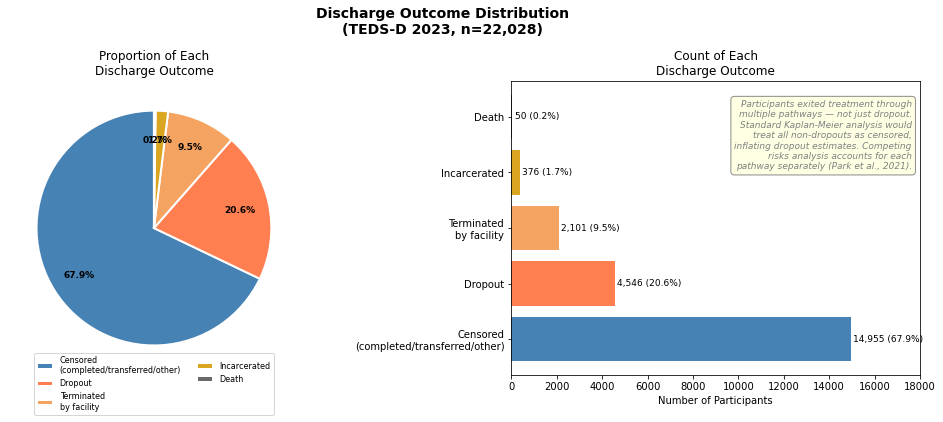

Saved: event_type_distribution.png


In [39]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 5: EVENT TYPE DISTRIBUTION CHART
# Justifies competing risks framework
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Discharge Outcome Distribution\n(TEDS-D 2023, n=22,028)',
             fontsize=14, fontweight='bold')

events = {
    'Censored\n(completed/transferred/other)': 14955,
    'Dropout': 4546,
    'Terminated\nby facility': 2101,
    'Incarcerated': 376,
    'Death': 50
}
labels = list(events.keys())
values = list(events.values())
percentages = [v / sum(values) * 100 for v in values]
colors = ['steelblue', 'coral', 'sandybrown', 'goldenrod', 'dimgray']

# Pie chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    values, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax.set_title('Proportion of Each\nDischarge Outcome', fontsize=12)
ax.legend(wedges, labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.15), fontsize=8, ncol=2)

# Bar graph
ax = axes[1]
bars = ax.barh(labels, values, color=colors)
ax.set_xlabel('Number of Participants')
ax.set_title('Count of Each\nDischarge Outcome', fontsize=12)
ax.set_xlim(0, 18000)
for bar, val, pct in zip(bars, values, percentages):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.annotate(
    'Participants exited treatment through\n'
    'multiple pathways — not just dropout.\n'
    'Standard Kaplan-Meier analysis would\n'
    'treat all non-dropouts as censored,\n'
    'inflating dropout estimates. Competing\n'
    'risks analysis accounts for each\n'
    'pathway separately (Park et al., 2021).',
    xy=(0.98, 0.70), xycoords='axes fraction',
    fontsize=9, color='gray', style='italic', ha='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
              edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('event_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: event_type_distribution.png")

In [40]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# increase jitter to better resolve ties for AalenJohansen
np.random.seed(42)
df['LOS_days_aj'] = df['LOS_days'] + np.random.uniform(0, 1.0, size=len(df))
print(f"Extended jitter applied: {df['LOS_days_aj'].min():.2f} to {df['LOS_days_aj'].max():.2f}")
print(f"Unique LOS values: {df['LOS_days_aj'].nunique()}")

Extended jitter applied: 1.00 to 549.50
Unique LOS values: 22028


Fitting overall CIF curve...
Overall fit complete


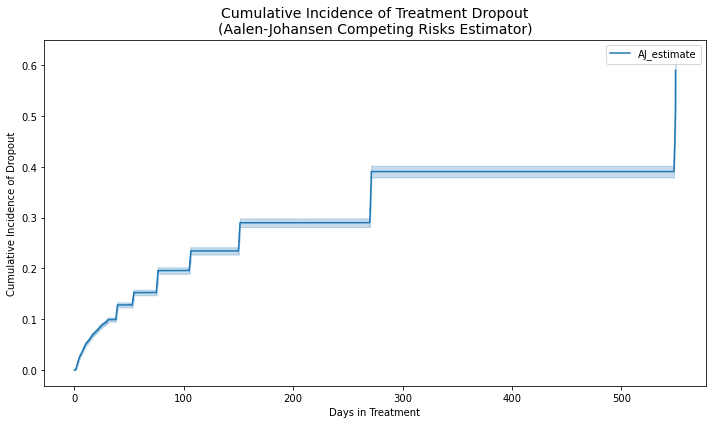


Cumulative incidence of dropout at key timepoints:
  Day   7: 3.5% cumulative dropout
  Day  14: 6.0% cumulative dropout
  Day  30: 9.6% cumulative dropout
  Day  60: 15.3% cumulative dropout
  Day  90: 19.6% cumulative dropout
  Day 180: 29.0% cumulative dropout
  Day 365: 39.1% cumulative dropout
  Day 548: 39.1% cumulative dropout

Cumulative incidence reaches 50% at: Day 549

Total participants: 22,028
Dropout events: 4,546
Censored: 14,955
Competing events: 2,527


In [41]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6: SURVIVAL CURVES — OVERALL
# ═══════════════════════════════════════════════════════════════

# GRAPHS LOAD BUT TAKE A LONG TIME

from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Fitting overall CIF curve...")
ajf = AalenJohansenFitter()
ajf.fit(
    durations=df['LOS_days_aj'],
    event_observed=df['event_type'],
    event_of_interest=1
)
print("Overall fit complete")

plt.figure(figsize=(10, 6))
ajf.plot_cumulative_density()
plt.title('Cumulative Incidence of Treatment Dropout\n'
          '(Aalen-Johansen Competing Risks Estimator)', fontsize=14)
plt.xlabel('Days in Treatment')
plt.ylabel('Cumulative Incidence of Dropout')
plt.tight_layout()
plt.savefig('competing_risks_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# cumulative incidence at key timepoints
print("\nCumulative incidence of dropout at key timepoints:")
ci = ajf.cumulative_density_
for t in [7, 14, 30, 60, 90, 180, 365, 548]:
    idx = ci.index[ci.index <= t]
    if len(idx) > 0:
        prob = ci.iloc[ci.index.get_loc(idx[-1]), 0]
        print(f"  Day {t:>3}: {prob:.1%} cumulative dropout")
    else:
        print(f"  Day {t:>3}: 0.0% (no events yet)")

above_50 = ci[ci.iloc[:, 0] >= 0.50]
if len(above_50) > 0:
    print(f"\nCumulative incidence reaches 50% at: Day {above_50.index[0]:.0f}")
else:
    print(f"\nCumulative incidence never reaches 50%")
    print(f"Highest cumulative incidence: {ci.iloc[:, 0].max():.1%}")

print(f"\nTotal participants: {len(df):,}")
print(f"Dropout events: {(df['event_type']==1).sum():,}")
print(f"Censored: {(df['event_type']==0).sum():,}")
print(f"Competing events: {(df['event_type']>1).sum():,}")


Fitting demographics curves...
  Sex done
  Race done
  Age done


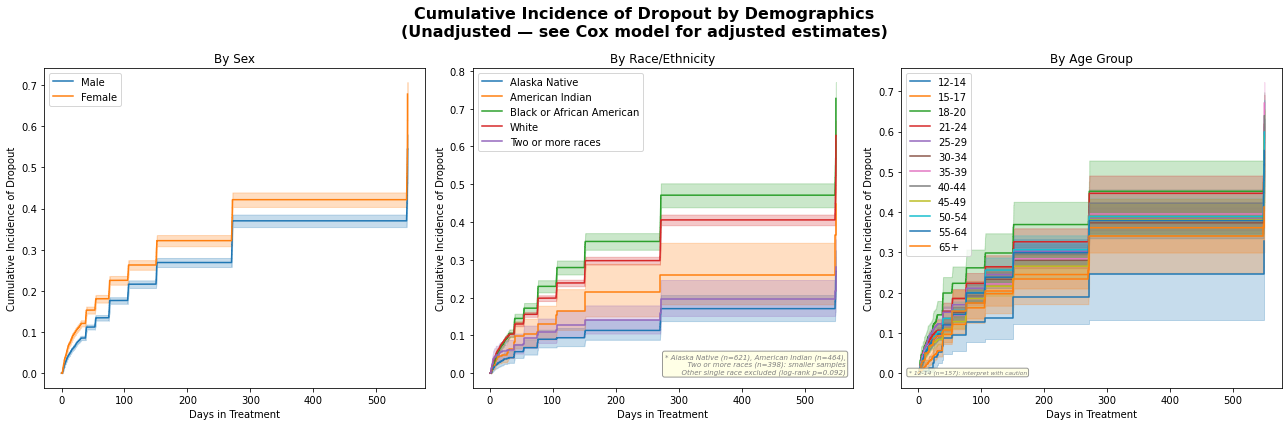

In [43]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6.1: SURVIVAL CURVES — Demographics Group
# ═══════════════════════════════════════════════════════════════

# GRAPHS LOAD BUT TAKE A LONG TIME

from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\nFitting demographics curves...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cumulative Incidence of Dropout by Demographics\n'
             '(Unadjusted — see Cox model for adjusted estimates)',
             fontsize=16, fontweight='bold')

ax = axes[0]
for code, label in {1: 'Male', 2: 'Female'}.items():
    mask = df['SEX'] == code
    ajf = AalenJohansenFitter()
    ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
            event_of_interest=1, label=label)
    ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Sex')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
print("  Sex done")

ax = axes[1]
for code, label in {1: 'Alaska Native', 2: 'American Indian',
                    4: 'Black or African American', 5: 'White',
                    8: 'Two or more races'}.items():
    mask = df['RACE'] == code
    if mask.sum() > 100:
        ajf = AalenJohansenFitter()
        ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
                event_of_interest=1, label=label)
        ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Race')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
ax.annotate('* Alaska Native (n=621), American Indian (n=464),\n'
            '  Two or more races (n=398): smaller samples\n'
            '  Other single race excluded (log-rank p=0.092)',
            xy=(0.98, 0.04), xycoords='axes fraction', fontsize=7,
            verticalalignment='bottom', ha='right', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
print("  Race done")

ax = axes[2]
age_bin_groups = {
    '12-14': df['AGE_years'] == 13, '15-17': df['AGE_years'] == 16,
    '18-20': df['AGE_years'] == 19, '21-24': df['AGE_years'] == 22,
    '25-29': df['AGE_years'] == 27, '30-34': df['AGE_years'] == 32,
    '35-39': df['AGE_years'] == 37, '40-44': df['AGE_years'] == 42,
    '45-49': df['AGE_years'] == 47, '50-54': df['AGE_years'] == 52,
    '55-64': df['AGE_years'] == 59, '65+': df['AGE_years'] == 70
}
for label, mask in age_bin_groups.items():
    if mask.sum() > 100:
        ajf = AalenJohansenFitter()
        ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
                event_of_interest=1, label=label)
        ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Age Group')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
ax.annotate('* 12-14 (n=157): interpret with caution',
            xy=(0.98, 0.04), xycoords='axes fraction', fontsize=7,
            verticalalignment='bottom', ha='right', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
print("  Age done")

plt.tight_layout()
plt.savefig('group_comparison_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


Fitting participant characteristics curves...
  Employment done
  PSYPROB done
  Insurance done
  Substance done


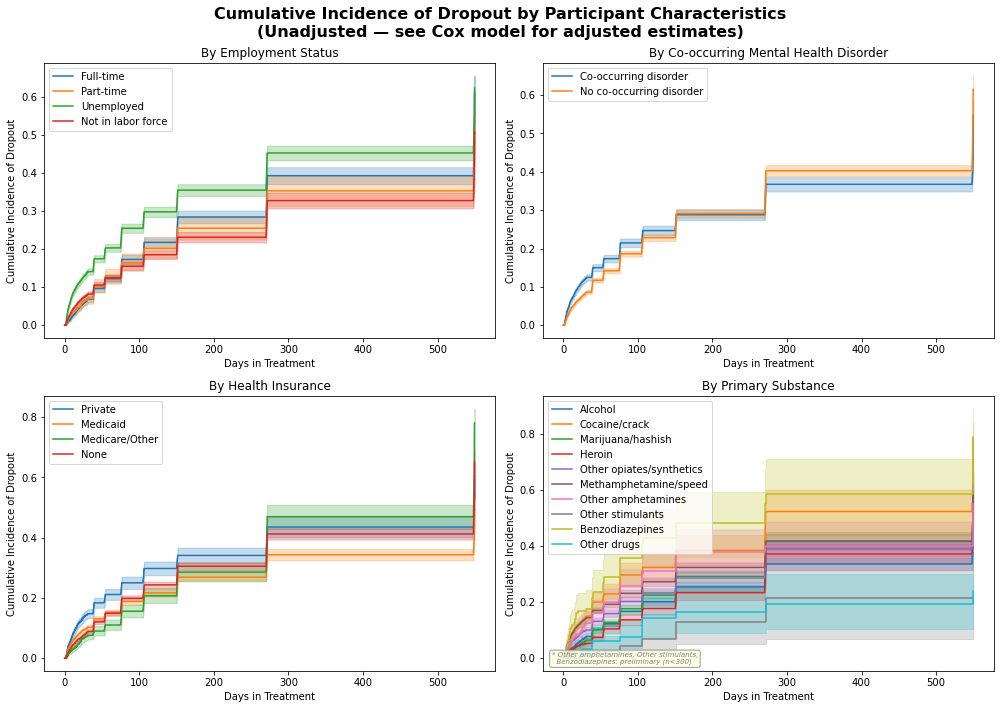

In [45]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6.2: SURVIVAL CURVES — Participant Characteristics Group
# ═══════════════════════════════════════════════════════════════

# GRAPHS LOAD BUT TAKE A LONG TIME

from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\nFitting participant characteristics curves...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cumulative Incidence of Dropout by Participant Characteristics\n'
             '(Unadjusted — see Cox model for adjusted estimates)',
             fontsize=16, fontweight='bold')

ax = axes[0, 0]
for code, label in {1: 'Full-time', 2: 'Part-time',
                    3: 'Unemployed', 4: 'Not in labor force'}.items():
    mask = df['EMPLOY'] == code
    ajf = AalenJohansenFitter()
    ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
            event_of_interest=1, label=label)
    ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Employment Status')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
print("  Employment done")

ax = axes[0, 1]
for code, label in {1: 'Co-occurring disorder',
                    2: 'No co-occurring disorder'}.items():
    mask = df['PSYPROB'] == code
    ajf = AalenJohansenFitter()
    ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
            event_of_interest=1, label=label)
    ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Co-occurring Mental Health Disorder')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
print("  PSYPROB done")

ax = axes[1, 0]
for code, label in {1: 'Private', 2: 'Medicaid',
                    3: 'Medicare/Other', 4: 'None'}.items():
    mask = df['HLTHINS'] == code
    ajf = AalenJohansenFitter()
    ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
            event_of_interest=1, label=label)
    ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Health Insurance')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
print("  Insurance done")

ax = axes[1, 1]
for code, label in {2: 'Alcohol', 3: 'Cocaine/crack', 4: 'Marijuana/hashish',
                    5: 'Heroin', 7: 'Other opiates/synthetics',
                    10: 'Methamphetamine/speed', 11: 'Other amphetamines',
                    12: 'Other stimulants', 13: 'Benzodiazepines',
                    19: 'Other drugs'}.items():
    mask = df['SUB1'] == code
    if mask.sum() > 100:
        ajf = AalenJohansenFitter()
        ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
                event_of_interest=1, label=label)
        ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Primary Substance')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
ax.annotate('* Other amphetamines, Other stimulants,\n'
            '  Benzodiazepines: preliminary (n<300)',
            xy=(0.98, 0.04), xycoords='axes fraction', fontsize=7,
            verticalalignment='bottom', ha='right', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
print("  Substance done")

plt.tight_layout()
plt.savefig('group_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Fitting treatment context curves...
  Referral done
  Services done
  Frequency done


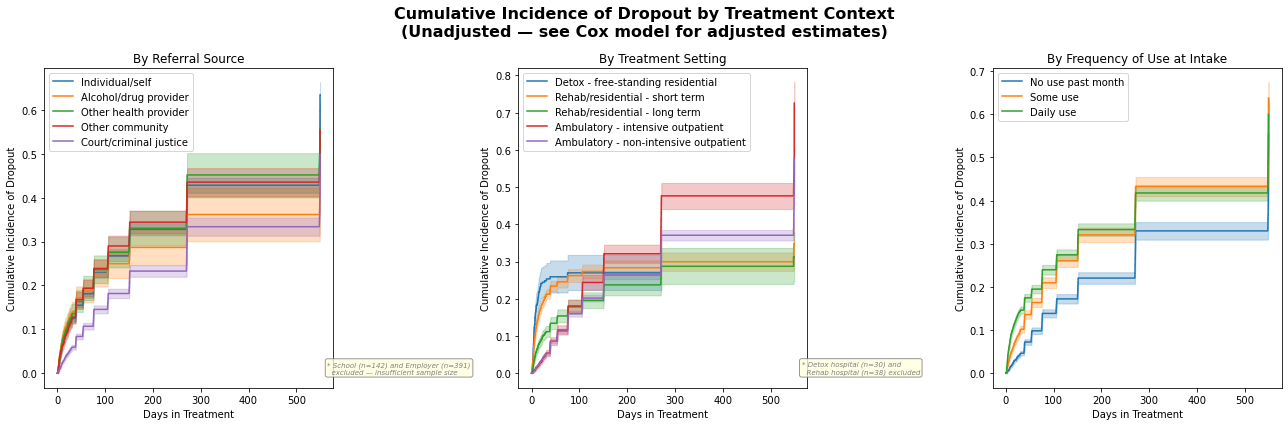

In [46]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6.3: SURVIVAL CURVES — Treatment Context Group
# ═══════════════════════════════════════════════════════════════

# GRAPHS LOAD BUT TAKE A LONG TIME

from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\nFitting treatment context curves...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cumulative Incidence of Dropout by Treatment Context\n'
             '(Unadjusted — see Cox model for adjusted estimates)',
             fontsize=16, fontweight='bold')

ax = axes[0]
for code, label in {1: 'Individual/self', 2: 'Alcohol/drug provider',
                    3: 'Other health provider', 6: 'Other community',
                    7: 'Court/criminal justice'}.items():
    mask = df['PSOURCE'] == code
    if mask.sum() > 100:
        ajf = AalenJohansenFitter()
        ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
                event_of_interest=1, label=label)
        ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Referral Source')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
ax.annotate('* School (n=142) and Employer (n=391)\n'
            '  excluded — insufficient sample size',
            xy=(0.98, 0.04), xycoords='axes fraction', fontsize=7,
            verticalalignment='bottom', ha='right', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
print("  Referral done")

ax = axes[1]
for code, label in {2: 'Detox - free-standing residential',
                    4: 'Rehab/residential - short term',
                    5: 'Rehab/residential - long term',
                    6: 'Ambulatory - intensive outpatient',
                    7: 'Ambulatory - non-intensive outpatient',
                    8: 'Ambulatory - detoxification'}.items():
    mask = df['SERVICES'] == code
    if mask.sum() > 100:
        ajf = AalenJohansenFitter()
        ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
                event_of_interest=1, label=label)
        ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Treatment Setting')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
ax.annotate('* Detox hospital (n=30) and\n'
            '  Rehab hospital (n=38) excluded',
            xy=(0.98, 0.04), xycoords='axes fraction', fontsize=7,
            verticalalignment='bottom', ha='right', color='gray', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))
print("  Services done")

ax = axes[2]
for code, label in {1: 'No use past month', 2: 'Some use',
                    3: 'Daily use'}.items():
    mask = df['FREQ1'] == code
    ajf = AalenJohansenFitter()
    ajf.fit(df.loc[mask, 'LOS_days_aj'], df.loc[mask, 'event_type'],
            event_of_interest=1, label=label)
    ajf.plot_cumulative_density(ax=ax)
ax.set_title('By Frequency of Use at Intake')
ax.set_xlabel('Days in Treatment')
ax.set_ylabel('Cumulative Incidence of Dropout')
print("  Frequency done")

plt.tight_layout()
plt.savefig('group_comparison_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 7: LOG-RANK TESTS — UNIVARIABLE GROUP COMPARISONS
# These are unadjusted analyses. Where results differ from
# the multivariable Cox model, Cox results take precedence
# (Park et al., 2021 — Mistake 6)
# ═══════════════════════════════════════════════════════════════

from lifelines.statistics import logrank_test

print("=" * 60)
print("LOG-RANK TESTS — UNIVARIABLE ANALYSES")
print("Note: log-rank tests compare full survival curves across")
print("the entire follow-up period, NOT specific timepoints.")
print("p-values should not be cited alongside specific survival")
print("probabilities at fixed timepoints (Park et al., 2021).")
print("For adjusted estimates, see Cox model results.")
print("=" * 60)

def run_logrank(group1_mask, group2_mask, label1, label2, variable):
    result = logrank_test(
        df.loc[group1_mask, 'LOS_days'],
        df.loc[group2_mask, 'LOS_days'],
        event_observed_A=df.loc[group1_mask, 'dropped_out'],
        event_observed_B=df.loc[group2_mask, 'dropped_out']
    )
    sig = '*** SIGNIFICANT' if result.p_value < 0.05 else 'not significant'
    print(f"  {label1} vs {label2}: p={result.p_value:.4f} ({sig})")

# Demographics
print("\nSEX")
run_logrank(df['SEX']==1, df['SEX']==2, 'Male', 'Female', 'SEX')

print("\nRACE/ETHNICITY (reference: White — largest group)")
for code, label in {4: 'Black or African American', 1: 'Alaska Native',
                    2: 'American Indian', 6: 'Asian',
                    7: 'Other single race', 8: 'Two or more races'}.items():
    mask = df['RACE'] == code
    if mask.sum() > 100:
        run_logrank(mask, df['RACE']==5, label, 'White', 'RACE')

print("\nAGE GROUP (reference: 35-39 — middle range, largest group)")
age_ref = df['AGE_years'] == 37
for label, mask in {
    '12-14': df['AGE_years'] == 13, '15-17': df['AGE_years'] == 16,
    '18-20': df['AGE_years'] == 19, '21-24': df['AGE_years'] == 22,
    '25-29': df['AGE_years'] == 27, '30-34': df['AGE_years'] == 32,
    '40-44': df['AGE_years'] == 42, '45-49': df['AGE_years'] == 47,
    '50-54': df['AGE_years'] == 52, '55-64': df['AGE_years'] == 59,
    '65+': df['AGE_years'] == 70
}.items():
    if mask.sum() > 100:
        run_logrank(mask, age_ref, label, '35-39', 'AGE')

# Participant characteristics
print("\nEMPLOYMENT STATUS (reference: Full-time)")
for code, label in {2: 'Part-time', 3: 'Unemployed',
                    4: 'Not in labor force'}.items():
    run_logrank(df['EMPLOY']==code, df['EMPLOY']==1,
                label, 'Full-time', 'EMPLOY')

print("\nCO-OCCURRING MENTAL HEALTH DISORDER")
run_logrank(df['PSYPROB']==1, df['PSYPROB']==2,
            'Co-occurring disorder', 'No co-occurring disorder', 'PSYPROB')

print("\nHEALTH INSURANCE (reference: Private)")
for code, label in {2: 'Medicaid', 3: 'Medicare/Other', 4: 'None'}.items():
    run_logrank(df['HLTHINS']==code, df['HLTHINS']==1,
                label, 'Private', 'HLTHINS')

print("\nPRIMARY SUBSTANCE (reference: Alcohol — most common)")
for code, label in {3: 'Cocaine/crack', 4: 'Marijuana/hashish',
                    5: 'Heroin', 7: 'Other opiates/synthetics',
                    10: 'Methamphetamine/speed', 11: 'Other amphetamines',
                    12: 'Other stimulants', 13: 'Benzodiazepines',
                    19: 'Other drugs'}.items():
    mask = df['SUB1'] == code
    if mask.sum() > 100:
        run_logrank(mask, df['SUB1']==2, label, 'Alcohol', 'SUB1')

# Treatment context
print("\nREFERRAL SOURCE (reference: Individual/self)")
for code, label in {2: 'Alcohol/drug provider', 3: 'Other health provider',
                    6: 'Other community', 7: 'Court/criminal justice'}.items():
    mask = df['PSOURCE'] == code
    if mask.sum() > 100:
        run_logrank(mask, df['PSOURCE']==1, label, 'Individual/self', 'PSOURCE')

print("\nTREATMENT SETTING (reference: Ambulatory non-intensive — largest group)")
for code, label in {2: 'Detox - free-standing residential',
                    4: 'Rehab/residential - short term',
                    5: 'Rehab/residential - long term',
                    6: 'Ambulatory - intensive outpatient',
                    8: 'Ambulatory - detoxification'}.items():
    mask = df['SERVICES'] == code
    if mask.sum() > 100:
        run_logrank(mask, df['SERVICES']==7,
                    label, 'Ambulatory non-intensive', 'SERVICES')

print("\nFREQUENCY OF USE AT INTAKE (reference: Daily use — most severe)")
for code, label in {1: 'No use past month', 2: 'Some use'}.items():
    run_logrank(df['FREQ1']==code, df['FREQ1']==3, label, 'Daily use', 'FREQ1')

print("\n" + "=" * 60)
print("IMPORTANT: Log-rank tests are univariable analyses.")
print("They compare unadjusted survival curves and do not")
print("control for confounding. Variables significant here")
print("but not in the Cox model had effects explained by")
print("other variables when controlled simultaneously.")
print("=" * 60)

LOG-RANK TESTS — UNIVARIABLE ANALYSES
Note: log-rank tests compare full survival curves across
the entire follow-up period, NOT specific timepoints.
p-values should not be cited alongside specific survival
probabilities at fixed timepoints (Park et al., 2021).
For adjusted estimates, see Cox model results.

SEX
  Male vs Female: p=0.0000 (*** SIGNIFICANT)

RACE/ETHNICITY (reference: White — largest group)
  Black or African American vs White: p=0.0000 (*** SIGNIFICANT)
  Alaska Native vs White: p=0.0000 (*** SIGNIFICANT)
  American Indian vs White: p=0.0013 (*** SIGNIFICANT)
  Other single race vs White: p=0.0916 (not significant)
  Two or more races vs White: p=0.0000 (*** SIGNIFICANT)

AGE GROUP (reference: 35-39 — middle range, largest group)
  12-14 vs 35-39: p=0.0173 (*** SIGNIFICANT)
  15-17 vs 35-39: p=0.0104 (*** SIGNIFICANT)
  18-20 vs 35-39: p=0.0006 (*** SIGNIFICANT)
  21-24 vs 35-39: p=0.0053 (*** SIGNIFICANT)
  25-29 vs 35-39: p=0.2824 (not significant)
  30-34 vs 35-39: p

In [48]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 8: SURVIVAL TIME TABLES
# ═══════════════════════════════════════════════════════════════

from lifelines import KaplanMeierFitter
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def get_survival_stats(mask):
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'LOS_days'], df.loc[mask, 'dropped_out'])
    median = kmf.median_survival_time_
    sf = kmf.survival_function_
    below_75 = sf[sf['KM_estimate'] <= 0.75]
    p25_day = below_75.index[0] if len(below_75) > 0 else None
    below_90 = sf[sf['KM_estimate'] <= 0.90]
    p10_day = below_90.index[0] if len(below_90) > 0 else None
    if np.isinf(median) or np.isnan(median):
        return None, p25_day, p10_day
    return median, p25_day, p10_day

def survival_table(var, group_codes, group_labels,
                   section_title, min_n=0):
    rows = []
    for code, label in zip(group_codes, group_labels):
        mask = (df['AGE_years'] == code if var == 'AGE_years'
                else df[var] == code)
        if mask.sum() < min_n:
            continue
        n = mask.sum()
        dropout_rate = df.loc[mask, 'dropped_out'].mean() * 100
        median, p25_day, p10_day = get_survival_stats(mask)
        rows.append({
            'Group': label,
            'n': f"{n:,}",
            'Dropout Rate': f"{dropout_rate:.1f}%",
            'Day 10% Dropped Out': f"{p10_day:.0f}" if p10_day else '>548',
            'Day 25% Dropped Out': f"{p25_day:.0f}" if p25_day else '>548',
            'Median (Day 50%)': f"{median:.0f}" if median else '>548*'
        })
    df_out = pd.DataFrame(rows).set_index('Group')
    print(f"\n{section_title}")
    print(df_out.to_string())
    return df_out

print("=" * 70)
print("SURVIVAL TIME TABLES")
print("Day 10% = day by which 10% of group had dropped out")
print("Day 25% = day by which 25% of group had dropped out")
print("Median  = day by which 50% had dropped out")
print(">548*   = curve never reached threshold (good retention)")
print("NOTE: Median survival times supplement the Cox model and")
print("are presented for descriptive clarity only.")
print("=" * 70)

kmf_all = KaplanMeierFitter()
kmf_all.fit(df['LOS_days'], df['dropped_out'])
sf_all = kmf_all.survival_function_
p10 = sf_all[sf_all['KM_estimate'] <= 0.90].index[0]
p25 = sf_all[sf_all['KM_estimate'] <= 0.75].index[0]
print(f"\nOVERALL SAMPLE (n=22,028, dropout rate=20.6%)")
print(f"  Day 10% dropped out: {p10:.0f} days")
print(f"  Day 25% dropped out: {p25:.0f} days")
print(f"  Median (50%):        >548 days (curve never reached 50%)")

survival_table('SEX', [1, 2], ['Male', 'Female'], 'SEX')
survival_table('EMPLOY', [1, 2, 3, 4],
               ['Full-time', 'Part-time', 'Unemployed', 'Not in labor force'],
               'EMPLOYMENT STATUS')
survival_table('HLTHINS', [1, 2, 3, 4],
               ['Private', 'Medicaid', 'Medicare/Other', 'None'],
               'HEALTH INSURANCE')
survival_table('SUB1', [2, 3, 4, 5, 7, 10, 11, 12, 13, 19],
               ['Alcohol', 'Cocaine/crack', 'Marijuana/hashish', 'Heroin',
                'Other opiates/synthetics', 'Methamphetamine/speed',
                'Other amphetamines', 'Other stimulants',
                'Benzodiazepines', 'Other drugs'],
               'PRIMARY SUBSTANCE', min_n=100)
survival_table('PSYPROB', [1, 2],
               ['Co-occurring disorder', 'No co-occurring disorder'],
               'CO-OCCURRING MENTAL HEALTH DISORDER')
survival_table('PSOURCE', [1, 2, 3, 6, 7],
               ['Individual/self', 'Alcohol/drug provider',
                'Other health provider', 'Other community',
                'Court/criminal justice'],
               'REFERRAL SOURCE', min_n=100)
survival_table('SERVICES', [2, 4, 5, 6, 7, 8],
               ['Detox - free-standing residential',
                'Rehab/residential - short term',
                'Rehab/residential - long term',
                'Ambulatory - intensive outpatient',
                'Ambulatory - non-intensive outpatient',
                'Ambulatory - detoxification'],
               'TREATMENT SETTING', min_n=100)
survival_table('FREQ1', [1, 2, 3],
               ['No use past month', 'Some use', 'Daily use'],
               'FREQUENCY OF USE AT INTAKE')
survival_table('RACE', [1, 2, 4, 5, 7, 8],
               ['Alaska Native', 'American Indian',
                'Black or African American', 'White',
                'Other single race', 'Two or more races'],
               'RACE/ETHNICITY', min_n=100)
survival_table('AGE_years',
               [13, 16, 19, 22, 27, 32, 37, 42, 47, 52, 59, 70],
               ['12-14', '15-17', '18-20', '21-24', '25-29', '30-34',
                '35-39', '40-44', '45-49', '50-54', '55-64', '65+'],
               'AGE GROUP', min_n=100)

print("\n" + "=" * 70)
print("* >548 = group retained well enough that threshold was")
print("  never reached within the observation period.")
print("=" * 70)

SURVIVAL TIME TABLES
Day 10% = day by which 10% of group had dropped out
Day 25% = day by which 25% of group had dropped out
Median  = day by which 50% had dropped out
>548*   = curve never reached threshold (good retention)
NOTE: Median survival times supplement the Cox model and
are presented for descriptive clarity only.

OVERALL SAMPLE (n=22,028, dropout rate=20.6%)
  Day 10% dropped out: 30 days
  Day 25% dropped out: 105 days
  Median (50%):        >548 days (curve never reached 50%)

SEX
             n Dropout Rate Day 10% Dropped Out Day 25% Dropped Out Median (Day 50%)
Group                                                                               
Male    13,340        18.5%                  38                 150              548
Female   8,688        23.9%                  21                 105              548

EMPLOYMENT STATUS
                        n Dropout Rate Day 10% Dropped Out Day 25% Dropped Out Median (Day 50%)
Group                                        

In [49]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 9: COX MODEL — DUMMY CODING
# Must run before Block 10 (stratified Cox model)
# ═══════════════════════════════════════════════════════════════

import pandas as pd

# safety check
try:
    assert 'LOS_days' in df.columns
    assert 'dropped_out' in df.columns
    assert 'event_type' in df.columns
    print("✓ df confirmed — proceeding with Cox model preparation")
except (NameError, AssertionError):
    print("ERROR: Run Block 1 first")

cox_df = df[['LOS_days', 'dropped_out',
             'AGE_years', 'SEX', 'RACE',
             'EMPLOY', 'PSYPROB', 'HLTHINS',
             'SUB1', 'PSOURCE', 'SERVICES', 'FREQ1']].copy()

# RACE: White (5) is reference (largest group)
# Asian (n=78) and Native Hawaiian (n=63) absorbed into reference
# too small for stable estimates
cox_df['RACE_Black'] = (cox_df['RACE'] == 4).astype(int)
cox_df['RACE_AmericanIndian'] = (cox_df['RACE'] == 2).astype(int)
cox_df['RACE_AlaskaNative'] = (cox_df['RACE'] == 1).astype(int)
cox_df['RACE_TwoOrMore'] = (cox_df['RACE'] == 8).astype(int)
cox_df['RACE_OtherSingle'] = (cox_df['RACE'] == 7).astype(int)
cox_df = cox_df.drop(columns=['RACE'])

# SUB1: Alcohol (2) is reference (most common, n=5,768)
cox_df['SUB_Cocaine'] = (cox_df['SUB1'] == 3).astype(int)
cox_df['SUB_Marijuana'] = (cox_df['SUB1'] == 4).astype(int)
cox_df['SUB_Heroin'] = (cox_df['SUB1'] == 5).astype(int)
cox_df['SUB_OtherOpiates'] = (cox_df['SUB1'] == 7).astype(int)
cox_df['SUB_Meth'] = (cox_df['SUB1'] == 10).astype(int)
cox_df['SUB_OtherAmphetamines'] = (cox_df['SUB1'] == 11).astype(int)
cox_df['SUB_OtherStimulants'] = (cox_df['SUB1'] == 12).astype(int)
cox_df['SUB_Benzodiazepines'] = (cox_df['SUB1'] == 13).astype(int)
cox_df['SUB_OtherDrugs'] = (cox_df['SUB1'] == 19).astype(int)
cox_df = cox_df.drop(columns=['SUB1'])

# EMPLOY: Full-time (1) is reference
# non-linear relationship confirmed by raw rates
cox_df['EMPLOY_PartTime'] = (cox_df['EMPLOY'] == 2).astype(int)
cox_df['EMPLOY_Unemployed'] = (cox_df['EMPLOY'] == 3).astype(int)
cox_df['EMPLOY_NotInLaborForce'] = (cox_df['EMPLOY'] == 4).astype(int)
cox_df = cox_df.drop(columns=['EMPLOY'])

# HLTHINS: Private (1) is reference
# theoretically most advantaged group despite smaller n (n=2,409)
cox_df['HLTHINS_Medicaid'] = (cox_df['HLTHINS'] == 2).astype(int)
cox_df['HLTHINS_Medicare'] = (cox_df['HLTHINS'] == 3).astype(int)
cox_df['HLTHINS_None'] = (cox_df['HLTHINS'] == 4).astype(int)
cox_df['HLTHINS_Unknown'] = (cox_df['HLTHINS'] == 5).astype(int)
cox_df = cox_df.drop(columns=['HLTHINS'])

# PSYPROB: No co-occurring disorder (2) is reference
cox_df['PSYPROB_Yes'] = (cox_df['PSYPROB'] == 1).astype(int)
cox_df = cox_df.drop(columns=['PSYPROB'])

# PSOURCE: Individual/self (1) is reference
# School (4) and Employer (5) excluded — under 100 participants
cox_df['PSOURCE_AlcDrug'] = (cox_df['PSOURCE'] == 2).astype(int)
cox_df['PSOURCE_HealthProvider'] = (cox_df['PSOURCE'] == 3).astype(int)
cox_df['PSOURCE_Community'] = (cox_df['PSOURCE'] == 6).astype(int)
cox_df['PSOURCE_Court'] = (cox_df['PSOURCE'] == 7).astype(int)
cox_df = cox_df.drop(columns=['PSOURCE'])

# SERVICES: Ambulatory non-intensive (7) is reference (largest, n=11,857)
# Detox hospital (1, n=30) and Rehab hospital (3, n=38) excluded
cox_df['SERV_DetoxResidential'] = (cox_df['SERVICES'] == 2).astype(int)
cox_df['SERV_RehabShortTerm'] = (cox_df['SERVICES'] == 4).astype(int)
cox_df['SERV_RehabLongTerm'] = (cox_df['SERVICES'] == 5).astype(int)
cox_df['SERV_AmbIntensive'] = (cox_df['SERVICES'] == 6).astype(int)
cox_df['SERV_AmbDetox'] = (cox_df['SERVICES'] == 8).astype(int)
cox_df = cox_df.drop(columns=['SERVICES'])

# FREQ1: Daily use (3) is reference (highest raw dropout rate)
cox_df['FREQ_NoUse'] = (cox_df['FREQ1'] == 1).astype(int)
cox_df['FREQ_SomeUse'] = (cox_df['FREQ1'] == 2).astype(int)
cox_df = cox_df.drop(columns=['FREQ1'])

# SEX: Male (1) is reference
cox_df['SEX_Female'] = (cox_df['SEX'] == 2).astype(int)
cox_df = cox_df.drop(columns=['SEX'])

cox_df = cox_df.dropna()

# verify
required_cols = ['RACE_Black', 'EMPLOY_Unemployed', 'SUB_Cocaine',
                 'SERV_DetoxResidential', 'SEX_Female']
missing = [c for c in required_cols if c not in cox_df.columns]
if missing:
    print(f"ERROR: Missing columns: {missing}")
else:
    print(f"✓ All dummy columns present")
    print(f"✓ Cox model dataset: {len(cox_df):,} rows")
    print(f"✓ Dropout events: {cox_df['dropped_out'].sum():,}")
    print(f"✓ Variables in model: {len(cox_df.columns) - 2}")
    print(f"✓ Any NaN values: {cox_df.isna().sum().sum()}")

✓ df confirmed — proceeding with Cox model preparation
✓ All dummy columns present
✓ Cox model dataset: 22,028 rows
✓ Dropout events: 4,546
✓ Variables in model: 35
✓ Any NaN values: 0


=== STRATIFIED COX MODEL ===
Primary multivariable analysis — adjusted hazard ratios
Stratified by treatment setting (severe PH violations)

Strata distribution:
service_strata
AmbNonIntensive     11925
RehabShortTerm       4573
AmbIntensive         2967
RehabLongTerm        1843
DetoxResidential      638
AmbDetox               82
Name: count, dtype: int64

Variables in model: 30

=== STRATIFIED MODEL SUMMARY ===


AttributeError: The '.style' accessor requires jinja2

model,lifelines.CoxPHFitter
duration col,'LOS_days'
event col,'dropped_out'
penalizer,0.1
l1 ratio,0.0
strata,service_strata
baseline estimation,breslow
number of observations,22028
number of events observed,4546
partial log-likelihood,-35368.954
time fit was run,2026-05-24 00:15:31 UTC


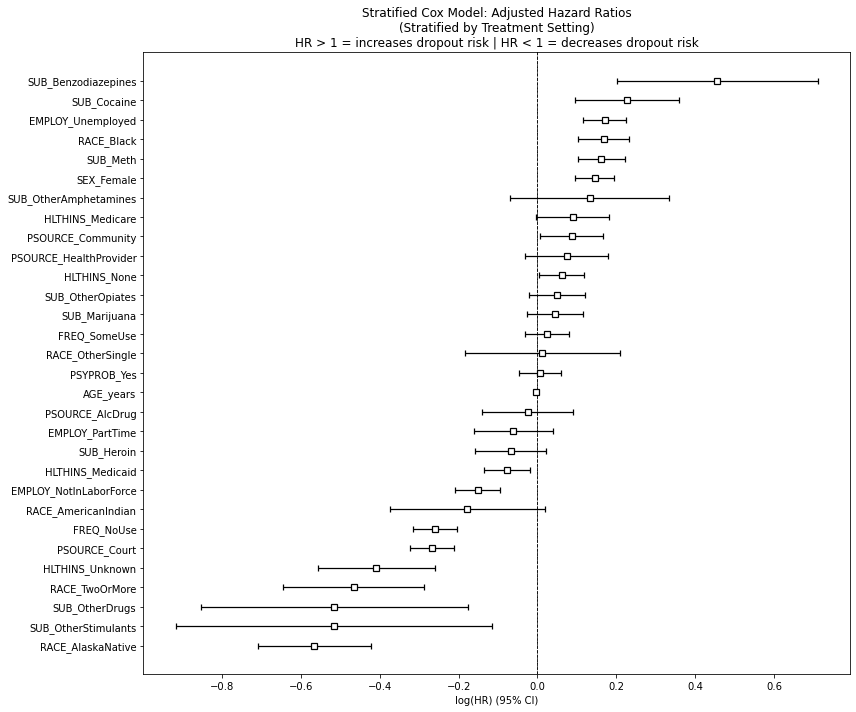


=== ADJUSTED HAZARD RATIO SUMMARY ===
HR > 1 = increases dropout risk vs reference group
HR < 1 = decreases dropout risk vs reference group
NOTE: AGE_years HR is per 1-year increase in age
Reference groups: White, Alcohol, Full-time, Private,
  No co-occurring disorder, Individual/self,
  Ambulatory non-intensive, Daily use, Male
---------------------------------------------------------------------------
                        Hazard Ratio  HR Lower 95%  HR Upper 95%  p-value Significant
covariate                                                                            
SUB_Benzodiazepines            1.578         1.224         2.035   0.0004     *** YES
SUB_Cocaine                    1.255         1.099         1.433   0.0008     *** YES
EMPLOY_Unemployed              1.186         1.122         1.253   0.0000     *** YES
RACE_Black                     1.182         1.108         1.261   0.0000     *** YES
SUB_Meth                       1.175         1.107         1.247   0.0000  

In [50]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 10: STRATIFIED COX PROPORTIONAL HAZARDS MODEL
# Stratified on treatment setting due to severe PH violations
# ═══════════════════════════════════════════════════════════════

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import matplotlib.pyplot as plt

print("=== STRATIFIED COX MODEL ===")
print("Primary multivariable analysis — adjusted hazard ratios")
print("Stratified by treatment setting (severe PH violations)")
print("=" * 60)

# creating strata column from service dummy columns
def get_service_group(row):
    if row['SERV_DetoxResidential'] == 1:
        return 'DetoxResidential'
    elif row['SERV_RehabShortTerm'] == 1:
        return 'RehabShortTerm'
    elif row['SERV_RehabLongTerm'] == 1:
        return 'RehabLongTerm'
    elif row['SERV_AmbIntensive'] == 1:
        return 'AmbIntensive'
    elif row['SERV_AmbDetox'] == 1:
        return 'AmbDetox'
    else:
        return 'AmbNonIntensive'

cox_df['service_strata'] = cox_df.apply(get_service_group, axis=1)
print("\nStrata distribution:")
print(cox_df['service_strata'].value_counts())

# droping service columns — cannot be both strata and predictors
service_cols = ['SERV_DetoxResidential', 'SERV_RehabShortTerm',
                'SERV_RehabLongTerm', 'SERV_AmbIntensive', 'SERV_AmbDetox']
cox_strat = cox_df.drop(columns=service_cols)
print(f"\nVariables in model: {len(cox_strat.columns) - 3}")

# fitting model
cph_strat = CoxPHFitter(penalizer=0.1)
cph_strat.fit(cox_strat,
              duration_col='LOS_days',
              event_col='dropped_out',
              strata='service_strata')

print("\n=== STRATIFIED MODEL SUMMARY ===")
cph_strat.print_summary(decimals=3)

# hazard ratio plot
plt.figure(figsize=(12, 10))
cph_strat.plot()
plt.title('Stratified Cox Model: Adjusted Hazard Ratios\n'
          '(Stratified by Treatment Setting)\n'
          'HR > 1 = increases dropout risk | HR < 1 = decreases dropout risk',
          fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('cox_stratified_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# cleaning hazard ratio table
print("\n=== ADJUSTED HAZARD RATIO SUMMARY ===")
print("HR > 1 = increases dropout risk vs reference group")
print("HR < 1 = decreases dropout risk vs reference group")
print("NOTE: AGE_years HR is per 1-year increase in age")
print("Reference groups: White, Alcohol, Full-time, Private,")
print("  No co-occurring disorder, Individual/self,")
print("  Ambulatory non-intensive, Daily use, Male")
print("-" * 75)

summary_strat = cph_strat.summary[['exp(coef)', 'exp(coef) lower 95%',
                                    'exp(coef) upper 95%', 'p']].copy()
summary_strat.columns = ['Hazard Ratio', 'HR Lower 95%', 'HR Upper 95%', 'p-value']
summary_strat = summary_strat.sort_values('Hazard Ratio', ascending=False)
summary_strat['Significant'] = summary_strat['p-value'].apply(
    lambda x: '*** YES' if x < 0.05 else 'no')
for col in ['Hazard Ratio', 'HR Lower 95%', 'HR Upper 95%']:
    summary_strat[col] = summary_strat[col].round(3)
summary_strat['p-value'] = summary_strat['p-value'].round(4)
print(summary_strat.to_string())

# age interpretation
hr_age = cph_strat.summary.loc['AGE_years', 'exp(coef)']
age_range = 57  # 70 - 13
total_effect = hr_age ** age_range
print(f"\nAGE_years INTERPRETATION (per Park et al., 2021 — Mistake 4):")
print(f"  HR per 1-year increase: {hr_age:.4f}")
print(f"  Effect per decade: {hr_age**10:.4f}")
print(f"  Cumulative effect across full age range (13-70 yrs):")
print(f"    HR = {total_effect:.3f} ({(1-total_effect)*100:.1f}% lower risk")
print(f"    for oldest vs youngest participants)")

In [51]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 11: PH ASSUMPTION RETEST AND MODEL COMPARISON
# ═══════════════════════════════════════════════════════════════

from lifelines.statistics import proportional_hazard_test

print("\n=== PROPORTIONAL HAZARDS ASSUMPTION RETEST ===")
print("Testing remaining variables after stratification")
print("p < 0.05 = assumption still violated")
print("-" * 60)

results_ph2 = proportional_hazard_test(
    cph_strat, cox_strat, time_transform='rank')

print("\nFull results:")
print(results_ph2.summary[['test_statistic', 'p']].round(4).to_string())

violations2 = results_ph2.summary[results_ph2.summary['p'] < 0.05]
print(f"\nViolations remaining: {len(violations2)} of {len(results_ph2.summary)}")
if len(violations2) > 0:
    print("\nStill violating:")
    print(violations2[['test_statistic', 'p']].round(4).to_string())
else:
    print("No violations remaining.")

print("\n=== MODEL COMPARISON ===")
print(f"Original Cox model concordance:    0.684")
print(f"Stratified Cox model concordance:  {cph_strat.concordance_index_:.3f}")
print(f"Original violations:               16 of 35")
print(f"Remaining violations:              {len(violations2)} of "
      f"{len(results_ph2.summary)}")
print(f"\nOriginal partial AIC:    80972.793")
print(f"Stratified partial AIC:  {cph_strat.AIC_partial_:.3f}")
print("Lower AIC = better model fit")
print("\nNote: Concordance decrease after stratification is expected.")
print("Treatment setting can no longer rank individuals across strata.")
print("AIC improvement confirms overall better model fit.")


=== PROPORTIONAL HAZARDS ASSUMPTION RETEST ===
Testing remaining variables after stratification
p < 0.05 = assumption still violated
------------------------------------------------------------

Full results:
                        test_statistic       p
AGE_years                       0.0099  0.9209
EMPLOY_NotInLaborForce          4.5640  0.0326
EMPLOY_PartTime                 0.8693  0.3512
EMPLOY_Unemployed              23.0773  0.0000
FREQ_NoUse                      5.8041  0.0160
FREQ_SomeUse                    7.3154  0.0068
HLTHINS_Medicaid               18.4095  0.0000
HLTHINS_Medicare               13.0499  0.0003
HLTHINS_None                    5.1617  0.0231
HLTHINS_Unknown                 0.6697  0.4132
PSOURCE_AlcDrug                 5.2392  0.0221
PSOURCE_Community               0.1881  0.6645
PSOURCE_Court                   4.8098  0.0283
PSOURCE_HealthProvider          0.0309  0.8604
PSYPROB_Yes                     0.1961  0.6579
RACE_AlaskaNative               6.5148